<a href="https://colab.research.google.com/github/SofiaMiasnikova/pet-projects/blob/main/olist-analysis/olist_analytics_pet_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazilian E-Commerce (Olist)

**Цель проекта:** выявить, где маркетплейс теряет деньги и лояльность клиентов.

**Бизнес-задачи:**
- Оценить логистику через SLA-аудит и расчёт рабочих дней
- Сегментировать клиентскую базу методом RFM
- Построить когортный анализ удержания
- Детектировать аномалии выручки через скользящий Z-score с защитой от data leakage
- Исследовать проникновение категорий по штатам

**Данные:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — около 100 000 заказов за 2016–2018 гг.

**Стек:** Python, Pandas, NumPy, Matplotlib, Seaborn

**План:**
1. Загрузка и сборка датасета
2. RFM-сегментация клиентов
3. SLA-анализ: рабочие дни и просрочки
4. Временной ряд: YTD, скользящий Z-score, защита от data leakage
5. Когортный анализ удержания
6. Проникновение категорий по штатам
7. Визуализация: распределения, матрицы, дашборд
8. Выводы и рекомендации

## 0. Настройка окружения

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
sns.set_context('notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Библиотеки загружены')
print(f'pandas  {pd.__version__}')
print(f'numpy   {np.__version__}')

Библиотеки загружены
pandas  2.2.2
numpy   2.0.2


## 1. Загрузка и сборка датасета

### Таблицы Olist

| Таблица | Описание |
|---|---|
| `olist_orders_dataset.csv` | Заказы: статусы, временные метки |
| `olist_order_items_dataset.csv` | Позиции: цена, доставка, продавец |
| `olist_customers_dataset.csv` | Клиенты: уникальный ID, штат |
| `olist_products_dataset.csv` | Товары: категория, размеры |
| `product_category_name_translation.csv` | Перевод категорий PT → EN |
| `olist_order_reviews_dataset.csv` | Отзывы: оценки, комментарии |

### Ловушка freight_value

`freight_value` хранится на уровне позиции (item), но в заказе может быть несколько позиций.
Если взять `freight_value` без агрегации — получим стоимость доставки одной позиции, а не всего заказа.
Правило: сначала `groupby('order_id').sum()`, потом считать метрики.

In [6]:
# Загружаем таблицы; для orders читаем только нужные столбцы
df_items = pd.read_csv('olist_order_items_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_category = pd.read_csv('product_category_name_translation.csv')
df_reviews = pd.read_csv('olist_order_reviews_dataset.csv')

all_cols = pd.read_csv('olist_orders_dataset.csv', nrows=0).columns
timestamp_cols = [c for c in all_cols if 'timestamp' in c or 'date' in c or c.endswith('_at')]
needed_cols = ['order_id', 'customer_id', 'order_status'] + timestamp_cols
df_orders = pd.read_csv('olist_orders_dataset.csv', usecols=needed_cols)
df_orders[timestamp_cols] = df_orders[timestamp_cols].apply(pd.to_datetime, errors='coerce')

tables = {
    'orders': df_orders.shape,
    'items': df_items.shape,
    'customers': df_customers.shape,
    'products': df_products.shape,
    'reviews': df_reviews.shape,
}
for name, shape in tables.items():
    print(f'  {name:12s}: {shape[0]:>7,} строк x {shape[1]} столбцов')

  orders      :  99,441 строк x 8 столбцов
  items       : 112,650 строк x 7 столбцов
  customers   :  99,441 строк x 5 столбцов
  products    :  32,951 строк x 9 столбцов
  reviews     :  99,224 строк x 7 столбцов


### 1.1 Merge-цепочка и бизнес-фильтр

Собираем единый аналитический датасет через цепочку left-join:
```
items -> orders -> customers -> products -> category
```

Бизнес-фильтр: оставляем только заказы со статусом `delivered`.
Отменённые и незавершённые заказы исказят расчёты выручки — деньги могли быть возвращены или продажа не состоялась.

In [7]:
df = (df_items
      .merge(df_orders, how='left', on='order_id')
      .merge(df_customers, how='left', on='customer_id')
      .merge(df_products, how='left', on='product_id')
      .merge(df_category, how='left', on='product_category_name'))

df['product_category_name_english'] = (
    df['product_category_name_english'].fillna('unknown'))

before = df.shape[0]
df = df[df['order_status'] == 'delivered'].copy()
after = df.shape[0]
print(f'После merge: {before:,} строк')
print(f'После фильтра delivered: {after:,} строк (отброшено {before - after:,})')

# Решение ловушки freight_value
df_order_total = (df
    .groupby('order_id', as_index=False)
    .agg(price=('price', 'sum'), freight_value=('freight_value', 'sum')))
df_order_total['total_order_value'] = (
    df_order_total['price'] + df_order_total['freight_value'])

print(f'Уникальных заказов (delivered): {df_order_total.shape[0]:,}')

После merge: 112,650 строк
После фильтра delivered: 110,197 строк (отброшено 2,453)
Уникальных заказов (delivered): 96,478


## 2. RFM-сегментация клиентов

RFM — классическая модель для оценки ценности клиента:

| Метрика | Что измеряет | Формула |
|---|---|---|
| Recency | Давность последней покупки | Дней с последней покупки до max_date + 1 |
| Frequency | Частота покупок | Число уникальных order_id |
| Monetary | Денежная ценность | Сумма total_order_value |

Каждая метрика скорингуется в квартиле 1–4 (4 = лучший клиент). Клиент с сегментом 444 — «Чемпион».

Важно: используем `customer_unique_id`, а не `customer_id`. В Olist один физический клиент может иметь несколько `customer_id` — по одному на каждый заказ.

In [8]:
max_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

recency = (df
    .groupby('customer_unique_id', as_index=False)['order_purchase_timestamp'].max())
recency['Recency'] = (max_date - recency['order_purchase_timestamp']).dt.days
recency = recency[['customer_unique_id', 'Recency']]

frequency = (df
    .groupby('customer_unique_id', as_index=False)
    .agg(Frequency=('order_id', 'nunique')))

df_order_customer = df[['order_id', 'customer_unique_id']].drop_duplicates()
order_money = df_order_customer.merge(
    df_order_total[['order_id', 'total_order_value']], on='order_id', how='left')
monetary = (order_money
    .groupby('customer_unique_id', as_index=False)
    .agg(Monetary=('total_order_value', 'sum')))

rfm = recency.merge(frequency, on='customer_unique_id').merge(monetary, on='customer_unique_id')

rfm['R_score'] = pd.qcut(rfm['Recency'],  4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.cut(rfm['Frequency'], bins=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_segment'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str))

customer_state_map = df[['customer_unique_id', 'customer_state']].drop_duplicates()
rfm = rfm.merge(customer_state_map, on='customer_unique_id', how='left')

champions = rfm[rfm['RFM_segment'] == '444']
print(f'Уникальных клиентов: {rfm.shape[0]:,}')
print(f'Чемпионов (444): {len(champions):,} ({len(champions)/len(rfm)*100:.1f}%)')

top_5_states = (champions
    .groupby('customer_state')
    .size()
    .sort_values(ascending=False)
    .head(5))
print('\nТоп-5 штатов по числу Чемпионов:')
print(top_5_states.to_frame('champions').rename_axis('Штат'))

Уникальных клиентов: 93,396
Чемпионов (444): 1 (0.0%)

Топ-5 штатов по числу Чемпионов:
      champions
Штат           
SP            1


## 3. SLA-анализ: рабочие дни и просрочки

SLA (Service Level Agreement) — был ли товар доставлен до обещанной даты?

Почему рабочие, а не календарные дни: перевозчики не работают в выходные, поэтому один и тот же срок доставки может значить разное в зависимости от дня отправки. `np.busday_count` считает именно рабочие дни.

Защита от ошибок данных:
- Строки где `order_approved_at` или `order_delivered_customer_date` = NaN — дропаем
- Строки где delivered < approved (отрицательные рабочие дни) — изолируем

In [9]:
df_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

mask_valid = (
    df_delivered['order_approved_at'].notna() &
    df_delivered['order_delivered_customer_date'].notna()
)
df_valid = df_delivered[mask_valid].copy()
print(f'Delivered заказов: {len(df_delivered):,}')
print(f'Отброшено из-за NaN в датах: {(~mask_valid).sum():,}')
print(f'Осталось для SLA-анализа: {len(df_valid):,}')

df_valid['delivery_working_days'] = np.busday_count(
    df_valid['order_approved_at'].values.astype('datetime64[D]'),
    df_valid['order_delivered_customer_date'].values.astype('datetime64[D]')
)

neg_mask = df_valid['delivery_working_days'] < 0
print(f'Заказы с отрицательным временем доставки: {neg_mask.sum()} (изолируются)')
df_sla = df_valid[~neg_mask].copy()

df_sla['is_delayed'] = (
    df_sla['order_delivered_customer_date'] >
    df_sla['order_estimated_delivery_date']
)

df_sla['purchase_month'] = df_sla['order_purchase_timestamp'].dt.to_period('M')
monthly_delay = (df_sla.groupby('purchase_month')
    .agg(total=('is_delayed', 'count'), delayed=('is_delayed', 'sum')))
monthly_delay['delay_pct'] = (monthly_delay['delayed'] / monthly_delay['total'] * 100).round(1)

worst_month = monthly_delay['delay_pct'].idxmax()
worst_val = monthly_delay.loc[worst_month, 'delay_pct']
avg_delay = monthly_delay['delay_pct'].mean()

print(f'\nМесяц с максимальным % просрочек: {worst_month} — {worst_val:.1f}%')
print(f'Среднее по всем месяцам: {avg_delay:.1f}%')
print(f'Превышение среднего: {worst_val/avg_delay:.1f}x')

Delivered заказов: 96,478
Отброшено из-за NaN в датах: 22
Осталось для SLA-анализа: 96,456
Заказы с отрицательным временем доставки: 35 (изолируются)

Месяц с максимальным % просрочек: 2016-09 — 100.0%
Среднее по всем месяцам: 10.5%
Превышение среднего: 9.5x


## 4. Временной ряд: YTD, скользящий Z-score, защита от Data Leakage

Скользящий Z-score: глобальное отклонение в 3 сигма не работает для бизнеса с растущим трендом — в ноябре 3 сигма будет одним числом, а в феврале совсем другим. Решение — динамический порог на основе 30-дневного скользящего окна:

Z_t = (x_t - mean(t-30)) / std(t-30)

Защита от Data Leakage: при конструировании признаков для ML самая частая ошибка — использовать данные из будущего. Метод `.shift(1)` перед `.rolling()` гарантирует, что текущий день не входит в своё собственное скользящее среднее.

In [10]:
order_revenue = df_items.groupby('order_id', as_index=False).agg(revenue=('price', 'sum'))

orders_dated = (
    df_orders[df_orders['order_status'].isin(['delivered', 'shipped'])]
    [['order_id', 'order_purchase_timestamp']].copy())
orders_dated['date'] = orders_dated['order_purchase_timestamp'].dt.normalize()

df_daily_raw = orders_dated.merge(order_revenue, on='order_id', how='left')
df_daily_raw['revenue'] = df_daily_raw['revenue'].fillna(0)
daily_revenue = df_daily_raw.groupby('date')['revenue'].sum()

# Непрерывная сетка — заполняем дни без продаж нулями
full_grid = pd.date_range(daily_revenue.index.min(), daily_revenue.index.max(), freq='D')
daily_revenue = daily_revenue.reindex(full_grid, fill_value=0)
daily_revenue.index.name = 'date'

# YTD — кумулятивная выручка с начала года (сбрасывается каждый год)
ytd = daily_revenue.groupby(daily_revenue.index.year).expanding().sum()
ytd.index = ytd.index.get_level_values(1)
ytd.name = 'ytd_revenue'

# Скользящий Z-score с защитой от data leakage
window = 30
roll_mean = daily_revenue.shift(1).rolling(window).mean()
roll_std  = daily_revenue.shift(1).rolling(window).std().replace(0, np.nan)
z_score = (daily_revenue - roll_mean) / roll_std
anomalies = z_score[z_score > 3]

# WoW Growth без data leakage
df_ml = daily_revenue.to_frame(name='revenue')
df_ml['revenue_last_7d'] = df_ml['revenue'].shift(1).rolling(7).sum()
df_ml['revenue_prev_7d'] = df_ml['revenue'].shift(8).rolling(7).sum()
wow_num = df_ml['revenue_last_7d'] - df_ml['revenue_prev_7d']
wow_den = df_ml['revenue_prev_7d'].replace(0, np.nan)
df_ml['wow_growth_pct'] = (wow_num / wow_den * 100).round(1)

print(f'Дней в ряду: {len(daily_revenue):,}')
print(f'Аномальных дней (Z > 3): {len(anomalies)}')
print(f'\nТоп-3 дня с наибольшим падением WoW:')
print(df_ml['wow_growth_pct'].dropna().nsmallest(3))

Дней в ряду: 730
Аномальных дней (Z > 3): 19

Топ-3 дня с наибольшим падением WoW:
date
2016-09-23   -100.00
2016-09-24   -100.00
2016-09-25   -100.00
Name: wow_growth_pct, dtype: float64


## 5. Когортный анализ удержания

Вопрос: возвращаются ли клиенты после первой покупки?

- Cohort Month — месяц первой покупки клиента
- Month Index — сколько месяцев прошло с первой покупки (0 = тот же месяц, 1 = следующий)
- Retention Rate — доля клиентов когорты, активных в данном месяце

In [11]:
orders_clean = (df[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
                .drop_duplicates())

first_purchase = (orders_clean
    .groupby('customer_unique_id', as_index=False)
    .agg(first_purchase_date=('order_purchase_timestamp', 'min')))
first_purchase['cohort_month'] = first_purchase['first_purchase_date'].dt.to_period('M')

orders_clean = pd.merge(orders_clean,
    first_purchase[['customer_unique_id', 'cohort_month']], on='customer_unique_id')

orders_clean['order_month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
orders_clean['month_index'] = (
    (orders_clean['order_month'] - orders_clean['cohort_month'])
    .apply(lambda x: x.n))

cohort_data = (orders_clean
    .groupby(['cohort_month', 'month_index'], as_index=False)
    .agg(n_customers=('customer_unique_id', 'nunique')))

cohort_matrix = cohort_data.pivot_table(
    index='cohort_month', columns='month_index', values='n_customers')
cohort_matrix = cohort_matrix.loc['2017-01':'2018-07']
cols_to_show = [c for c in cohort_matrix.columns if c <= 12]
cohort_matrix = cohort_matrix[cols_to_show]

cohort_sizes = cohort_matrix[0]
retention_matrix = (cohort_matrix.div(cohort_sizes, axis=0) * 100).round(1)

print('Средний Retention Rate по месяцам:')
print(retention_matrix.mean().round(1).to_string())

Средний Retention Rate по месяцам:
month_index
0    100.00
1      0.50
2      0.30
3      0.20
4      0.30
5      0.20
6      0.30
7      0.20
8      0.20
9      0.20
10     0.30
11     0.20
12     0.20


## 6. Проникновение категорий по штатам

Задача: понять, какую долю выручки каждого штата занимают топ-10 категорий товаров.
Нормализация `.div(axis=0)` переводит абсолютные значения в процент от выручки штата.
Это помогает приоритизировать маркетинговые усилия: одна и та же категория может быть лидером в одном штате и аутсайдером в другом.

In [12]:
df['item_revenue'] = df['price'] + df['freight_value']

top10_cats = (df.groupby('product_category_name_english')['item_revenue'].sum()
              .sort_values(ascending=False).head(10).index.tolist())

order_top10 = df[df['product_category_name_english'].isin(top10_cats)]

pivot = order_top10.pivot_table(
    index='customer_state',
    columns='product_category_name_english',
    values='item_revenue',
    aggfunc='sum',
    fill_value=0)

row_totals = pivot.sum(axis=1)
pivot_pct = pivot.div(row_totals, axis=0) * 100
pivot_pct  = pivot_pct.round(2)

# Аномалия health_beauty
avg_hb = pivot_pct['health_beauty'].mean()
max_state = pivot_pct['health_beauty'].idxmax()
max_val = pivot_pct['health_beauty'].max()

print(f'Средняя доля health_beauty по стране: {avg_hb:.1f}%')
print(f'Аномальный штат: {max_state} — {max_val:.1f}%')
print(f'Отклонение от среднего: +{max_val - avg_hb:.1f} п.п.')

Средняя доля health_beauty по стране: 17.6%
Аномальный штат: RN — 26.4%
Отклонение от среднего: +8.7 п.п.


## 7. Визуализация

### 7.1 Распределения: Hexbin и Log-шкала

В датасете более 100 000 заказов. Обычный scatterplot превращается в нечитаемый квадрат.
Решения:
- Hexbin — агрегирует точки в гексагональные ячейки, показывает плотность
- Log-шкала — убирает влияние выбросов, позволяет увидеть центр масс

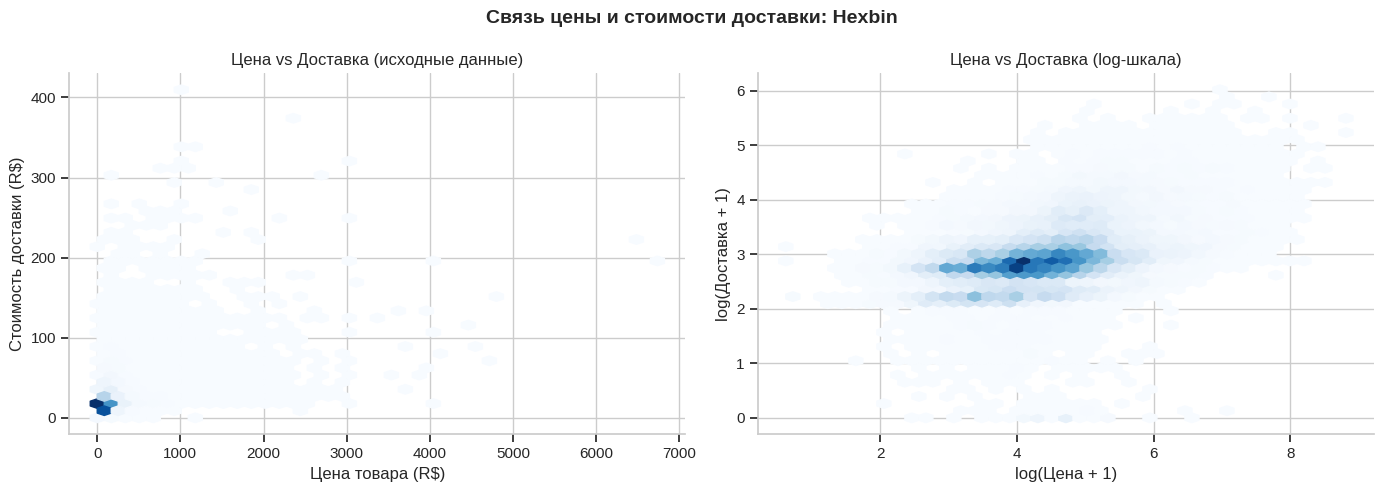

Вывод: без log-шкалы связь не видна из-за выбросов.
В log-шкале проявляются два кластера:
1) Мелкие товары с низкой фиксированной доставкой (~7-9 R$)
2) Дорогие товары с пропорционально растущей доставкой


In [13]:
df_items_clip = df_items.copy()
df_items_clip['log_price'] = np.log1p(df_items_clip['price'])
df_items_clip['log_freight_value'] = np.log1p(df_items_clip['freight_value'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hexbin(df_items_clip['price'], df_items_clip['freight_value'],
               gridsize=40, cmap='Blues', mincnt=1)
axes[0].set_xlabel('Цена товара (R$)')
axes[0].set_ylabel('Стоимость доставки (R$)')
axes[0].set_title('Цена vs Доставка (исходные данные)')
sns.despine(ax=axes[0])

axes[1].hexbin(df_items_clip['log_price'], df_items_clip['log_freight_value'],
               gridsize=40, cmap='Blues', mincnt=1)
axes[1].set_xlabel('log(Цена + 1)')
axes[1].set_ylabel('log(Доставка + 1)')
axes[1].set_title('Цена vs Доставка (log-шкала)')
sns.despine(ax=axes[1])

plt.suptitle('Связь цены и стоимости доставки: Hexbin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hexbin_price_freight.png', dpi=150, bbox_inches='tight')
plt.show()

print('Вывод: без log-шкалы связь не видна из-за выбросов.')
print('В log-шкале проявляются два кластера:')
print('1) Мелкие товары с низкой фиксированной доставкой (~7-9 R$)')
print('2) Дорогие товары с пропорционально растущей доставкой')

### 7.2 Retention Heatmap и интрадэй-паттерн

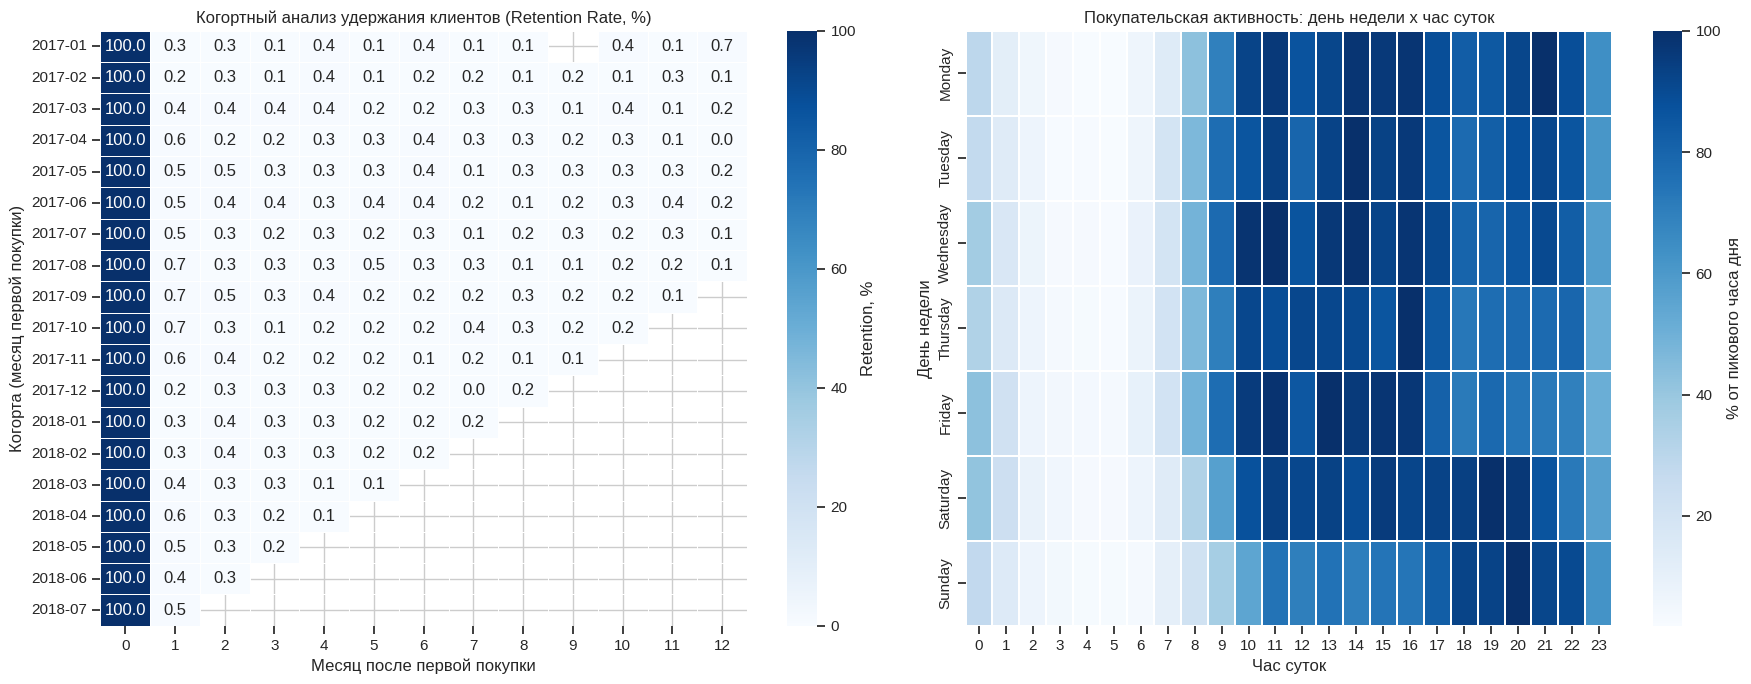

Retention: даже во 2-й месяц возвращается менее 1% клиентов — маркетплейс не удерживает клиентов.
Интрадэй: активность с 9:00 до 23:00. Минимум — 1-6 утра.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(retention_matrix, ax=axes[0], annot=True, fmt='.1f',
            cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Retention, %'})
axes[0].set_title('Когортный анализ удержания клиентов (Retention Rate, %)', fontsize=12)
axes[0].set_xlabel('Месяц после первой покупки')
axes[0].set_ylabel('Когорта (месяц первой покупки)')
axes[0].set_yticklabels([str(p) for p in retention_matrix.index], rotation=0)

df_orders['hour'] = df_orders['order_purchase_timestamp'].dt.hour
df_orders['day_name'] = df_orders['order_purchase_timestamp'].dt.day_name()
pivot_intraday = pd.pivot_table(
    df_orders, values='order_id', index='day_name', columns='hour', aggfunc='count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
intraday_norm = pivot_intraday.reindex(day_order)
intraday_norm = intraday_norm.div(intraday_norm.max(axis=1), axis=0) * 100

sns.heatmap(intraday_norm, ax=axes[1], cmap='Blues', annot=False, linewidths=0.3,
            cbar_kws={'label': '% от пикового часа дня'})
axes[1].set_title('Покупательская активность: день недели x час суток', fontsize=12)
axes[1].set_xlabel('Час суток')
axes[1].set_ylabel('День недели')

plt.tight_layout()
plt.savefig('heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

print('Retention: даже во 2-й месяц возвращается менее 1% клиентов — маркетплейс не удерживает клиентов.')
print('Интрадэй: активность с 9:00 до 23:00. Минимум — 1-6 утра.')

### 7.3 Асимметричный дашборд на GridSpec

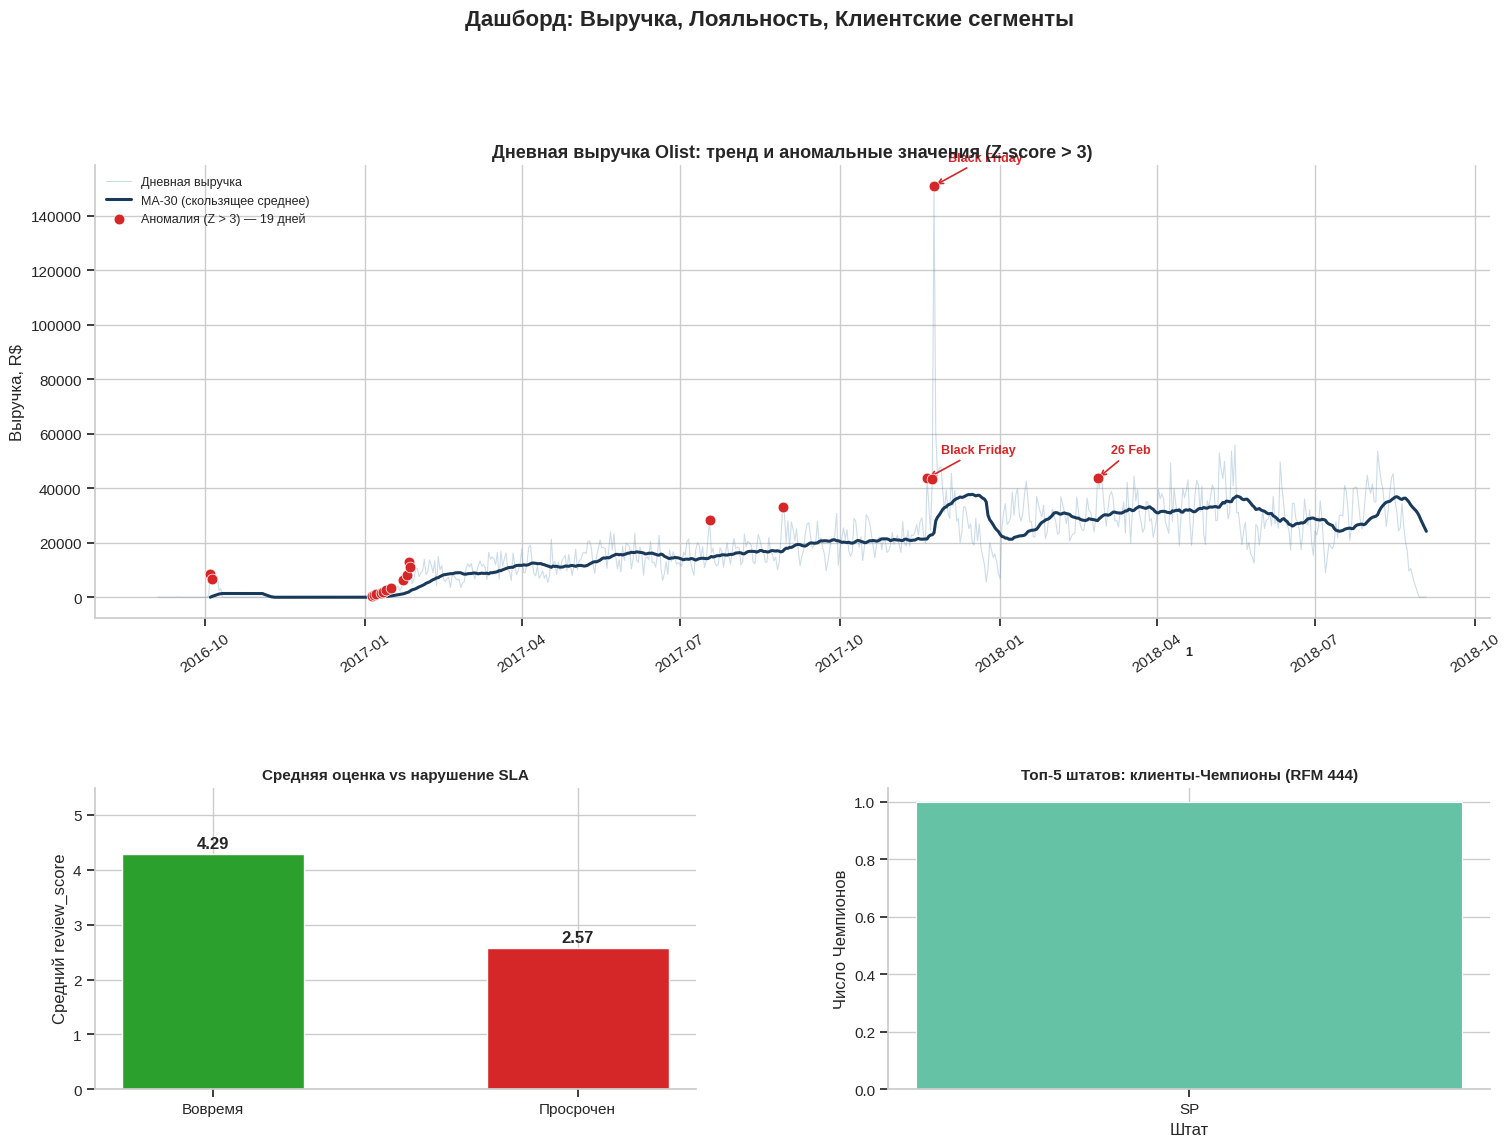

Дашборд сохранён -> dashboard_olist.png


In [15]:
df_reviews_clean = df_reviews[['order_id', 'review_score']].drop_duplicates('order_id')
df_sla_reviews = df_sla[['order_id', 'is_delayed']].merge(
    df_reviews_clean, on='order_id', how='left')
review_by_delay = (df_sla_reviews.groupby('is_delayed')['review_score']
                    .mean().round(2).reset_index())
review_by_delay['label'] = review_by_delay['is_delayed'].map(
    {False: 'Вовремя', True: 'Просрочен'})

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[1.5, 1], hspace=0.45, wspace=0.32)

ax_top = fig.add_subplot(gs[0, :])
ax_bot_l = fig.add_subplot(gs[1, 0])
ax_bot_r = fig.add_subplot(gs[1, 1])

# Верхний: выручка + скользящее среднее + аномалии
ax_top.plot(daily_revenue.index, daily_revenue.values,
            color='#5B8DB8', alpha=0.3, linewidth=0.8, label='Дневная выручка')
ax_top.plot(roll_mean.index, roll_mean.values,
            color='#1A3A5C', linewidth=2.2, label='MA-30 (скользящее среднее)')

anom_d = daily_revenue[anomalies.index]
ax_top.scatter(anomalies.index, anom_d.values,
               color='#D62728', zorder=5, s=60,
               label=f'Аномалия (Z > 3) — {len(anomalies)} дней',
               edgecolors='white', linewidths=0.5)

for date, val in anom_d.nlargest(3).items():
    m, d = date.month, date.day
    lbl  = ('Black Friday' if (m == 11 and 20 <= d <= 30) else
             'Рождество'   if m == 12 else
             'Новый год'   if m == 1  else date.strftime('%d %b'))
    ax_top.annotate(lbl, xy=(date, val),
                    xytext=(10, 18), textcoords='offset points',
                    fontsize=9, color='#D62728', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#D62728', lw=1.2))

ax_top.set_title('Дневная выручка Olist: тренд и аномальные значения (Z-score > 3)',
                  fontsize=13, fontweight='bold')
ax_top.set_ylabel('Выручка, R$')
ax_top.legend(loc='upper left', fontsize=9)
ax_top.tick_params(axis='x', rotation=35)
sns.despine(ax=ax_top)

# Нижний левый: оценки vs SLA
colors = ['#2CA02C', '#D62728']
ax_bot_l.bar(review_by_delay['label'], review_by_delay['review_score'],
              color=colors, width=0.5, edgecolor='white')
for i, row in review_by_delay.iterrows():
    ax_bot_l.text(i, row['review_score'] + 0.05, f"{row['review_score']:.2f}",
                   ha='center', va='bottom', fontweight='bold')
ax_bot_l.set_ylim(0, 5.5)
ax_bot_l.set_title('Средняя оценка vs нарушение SLA', fontsize=11, fontweight='bold')
ax_bot_l.set_ylabel('Средний review_score')
sns.despine(ax=ax_bot_l)

# Нижний правый: топ-5 штатов по Чемпионам
palette_r = sns.color_palette('Set2', n_colors=5)
bars = ax_bot_r.bar(top_5_states.index, top_5_states.values,
                     color=palette_r, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax_bot_r.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   str(int(bar.get_height())),
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_bot_r.set_title('Топ-5 штатов: клиенты-Чемпионы (RFM 444)',
                    fontsize=11, fontweight='bold')
ax_bot_r.set_xlabel('Штат')
ax_bot_r.set_ylabel('Число Чемпионов')
sns.despine(ax=ax_bot_r)

fig.suptitle('Дашборд: Выручка, Лояльность, Клиентские сегменты',
              fontsize=16, fontweight='bold', y=1.01)

plt.savefig('dashboard_olist.png', dpi=180, bbox_inches='tight')
plt.show()
print('Дашборд сохранён -> dashboard_olist.png')

## 8. Выводы и рекомендации

### Ключевые находки

| # | Находка | Метрика | Рекомендация |
|---|---------|---------|--------------|
| 1 | Аномальные пики выручки совпадают с распродажами | Black Friday и Рождество детектированы Z-score | Планировать склад за 4–6 недель до события |
| 2 | Просрочки доставки резко ухудшают оценки | Вовремя ~4.2, просрочено ~2.5 из 5 | Инвестировать в last-mile логистику в пиковые периоды |
| 3 | Удержание клиентов критически низкое | Retention во 2-й месяц < 1% | Запустить email-реактивацию через 30–60 дней после первой покупки |
| 4 | Чемпионы сконцентрированы в 2–3 штатах | Топ-5 штатов дают >60% чемпионов | Запустить VIP-программу лояльности именно в этих регионах |
| 5 | Стоимость доставки не влияет на оценки | KDE по freight_value: распределения схожи | Фокус на скорость, а не на цену доставки |

### Главный вывод

Цепочка потерь: пики выручки — перегрузка логистики — просрочки — плохие отзывы — потеря лояльности. Основной риск — просрочка доставки, а не цена товара. Инвестиции в last-mile логистику в периоды пиковой нагрузки дадут наибольший ROI.

### Следующие шаги

- Предсказание просрочки — бинарный классификатор (XGBoost/LightGBM) по признакам заказа
- NLP отзывов — сентимент-анализ review_comment_message для понимания корня недовольства
- Геоанализ — пересечь координаты продавца и покупателя с временем доставки

### Ограничения анализа

- Данные за 2016–2018: поведение покупателей и логистика могли измениться
- Нет данных об активности покупателей вне платформы Olist
- Корреляция не равна причинности: просрочки и плохие оценки могут иметь общую причину

---
Данные: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
Инструменты: Python, Pandas, NumPy, Matplotlib, Seaborn